# LeetCode #24: Swap Nodes in Pairs

https://leetcode.com/problems/swap-nodes-in-pairs/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Recursion** | $O(n)$ | $O(n)$ |
| **Iterative Dummy Head** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (Recursion)
Recursively swap the first two nodes, then recurse on the rest: `swap(head) = (head.next, head, swap(head.next.next))`. Clean and readable, but uses O(n) stack frames for a list of length n.

### Optimal: Iterative Dummy Head ★
Use a dummy node before `head` and a `prev` pointer that tracks the node just before the current pair. In each iteration: save `first = prev.next` and `second = prev.next.next`, re-wire three pointers to swap the pair, then advance `prev = first`. Single pass, O(1) extra space.

**Why dummy node?** It gives `prev` a valid position before the actual head, so the first pair is handled identically to every other pair — no special case for the new head.

**Constraints:**
* The number of nodes in the list is in the range $[0, 100]$
* $0 \leq$ Node.val $\leq 100$

## Solutions

### C#

In [ ]:
// Definition for singly-linked list.
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int val=0, ListNode next=null) { this.val = val; this.next = next; }
}

public class Solution {
    public ListNode SwapPairs(ListNode head) {
        var dummy = new ListNode(0, head);
        var prev = dummy;
        while (prev.next != null && prev.next.next != null) {
            var first  = prev.next;          // will become 2nd in swapped pair
            var second = prev.next.next;     // will become 1st in swapped pair
            first.next  = second.next;       // first skips past second
            second.next = first;             // second points back to first
            prev.next   = second;            // stitch swapped pair into chain
            prev = first;                    // advance prev (first is now tail of pair)
        }
        return dummy.next;
    }
}

### Python

In [ ]:
from typing import Optional

class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

class Solution:
    def swapPairs(self, head: Optional[ListNode]) -> Optional[ListNode]:
        dummy = ListNode(0, head)
        prev = dummy
        while prev.next and prev.next.next:
            first  = prev.next
            second = prev.next.next
            first.next  = second.next
            second.next = first
            prev.next   = second
            prev = first
        return dummy.next

### Go

In [ ]:
package main

type ListNode struct {
    Val  int
    Next *ListNode
}

func swapPairs(head *ListNode) *ListNode {
    dummy := &ListNode{Next: head}
    prev := dummy
    for prev.Next != nil && prev.Next.Next != nil {
        first  := prev.Next
        second := prev.Next.Next
        first.Next  = second.Next
        second.Next = first
        prev.Next   = second
        prev = first
    }
    return dummy.Next
}

### Rust

In [ ]:
// Definition for singly-linked list.
#[derive(PartialEq, Eq, Clone, Debug)]
pub struct ListNode {
    pub val: i32,
    pub next: Option<Box<ListNode>>,
}
impl ListNode {
    #[inline]
    fn new(val: i32) -> Self { ListNode { val, next: None } }
}

pub struct Solution;

impl Solution {
    pub fn swap_pairs(head: Option<Box<ListNode>>) -> Option<Box<ListNode>> {
        let mut dummy = Box::new(ListNode { val: 0, next: head });
        let mut prev = &mut dummy;
        while prev.next.is_some() && prev.next.as_ref().unwrap().next.is_some() {
            let mut first  = prev.next.take().unwrap();       // node 1
            let mut second = first.next.take().unwrap();      // node 2
            first.next  = second.next.take();                 // 1 -> rest
            second.next = Some(first);                        // 2 -> 1
            prev.next   = Some(second);                       // prev -> 2
            // advance prev to first (now tail of swapped pair)
            prev = prev.next.as_mut().unwrap().next.as_mut().unwrap();
        }
        dummy.next
    }
}

## Example Scenarios

### 1. Common Case — Even-Length List
**Input:** `1 -> 2 -> 3 -> 4`
Swap pair (1,2): prev.next = 2, 1.next = 3, 2.next = 1 → `2->1->3->4`. Then swap (3,4) the same way → `2->1->4->3`.
**Why tricky:** Straightforward test — interviewers use this to verify your basic pointer manipulation is correct before moving on.

**Output:** `2 -> 1 -> 4 -> 3` — $O(n)$ time, $O(1)$ space.

### 2. Slightly Complex — Odd-Length with Trailing Solo Node
**Input:** `1 -> 2 -> 3 -> 4 -> 5`
Pairs (1,2) and (3,4) swap normally. Node 5 has no partner, so the loop guard `prev.next && prev.next.next` fails, leaving 5 untouched → `2->1->4->3->5`.
**Why tricky:** The unpaired tail must survive without a null-pointer crash. Interviewers look for the correct two-condition loop guard.

**Output:** `2 -> 1 -> 4 -> 3 -> 5`

### 3. Edge Case: Time Factor — Maximum Length (n = 100)
**Input:** `1 -> 2 -> 3 -> ... -> 100` (100 nodes, constraint maximum)
The iterative approach performs exactly 50 swaps in a single pass, each requiring 3 pointer reassignments = 150 operations total.
**Why tricky:** Recursion would use $O(n)$ stack frames (50 calls). The iterative dummy-head approach stays at $O(1)$ space, which matters at scale.

**Output:** `2 -> 1 -> 4 -> 3 -> ... -> 100 -> 99` — 50 swaps, $O(n)$ time.

### 4. Edge Case: Space Factor — Single Node
**Input:** `[42]`
`prev.next` (node 42) exists, but `prev.next.next` is null → loop body never executes. Returns the list unchanged with zero allocations.
**Why tricky:** Verifies the double-condition guard. Recursive solutions still allocate one stack frame. Tests that $O(1)$ space holds even in degenerate cases.

**Output:** `[42]` — unchanged, $O(1)$ space.

### 5. Almost-Impossible but Plausible — Boundary Values Alternating
**Input:** `0 -> 100 -> 0 -> 100 -> 0` (values at constraint min/max: $0 \leq \text{val} \leq 100$)
After swaps: pair (0,100) → `100->0`, pair (0,100) → `100->0`, trailing 0 stays. Result: `100->0->100->0->0`.
**Why tricky:** Extreme boundary values with an odd count. The swap of (0,100) looks like a no-op to someone skimming output, but pointers have moved. Tests pointer correctness when values are at constraint limits.

**Output:** `100 -> 0 -> 100 -> 0 -> 0`

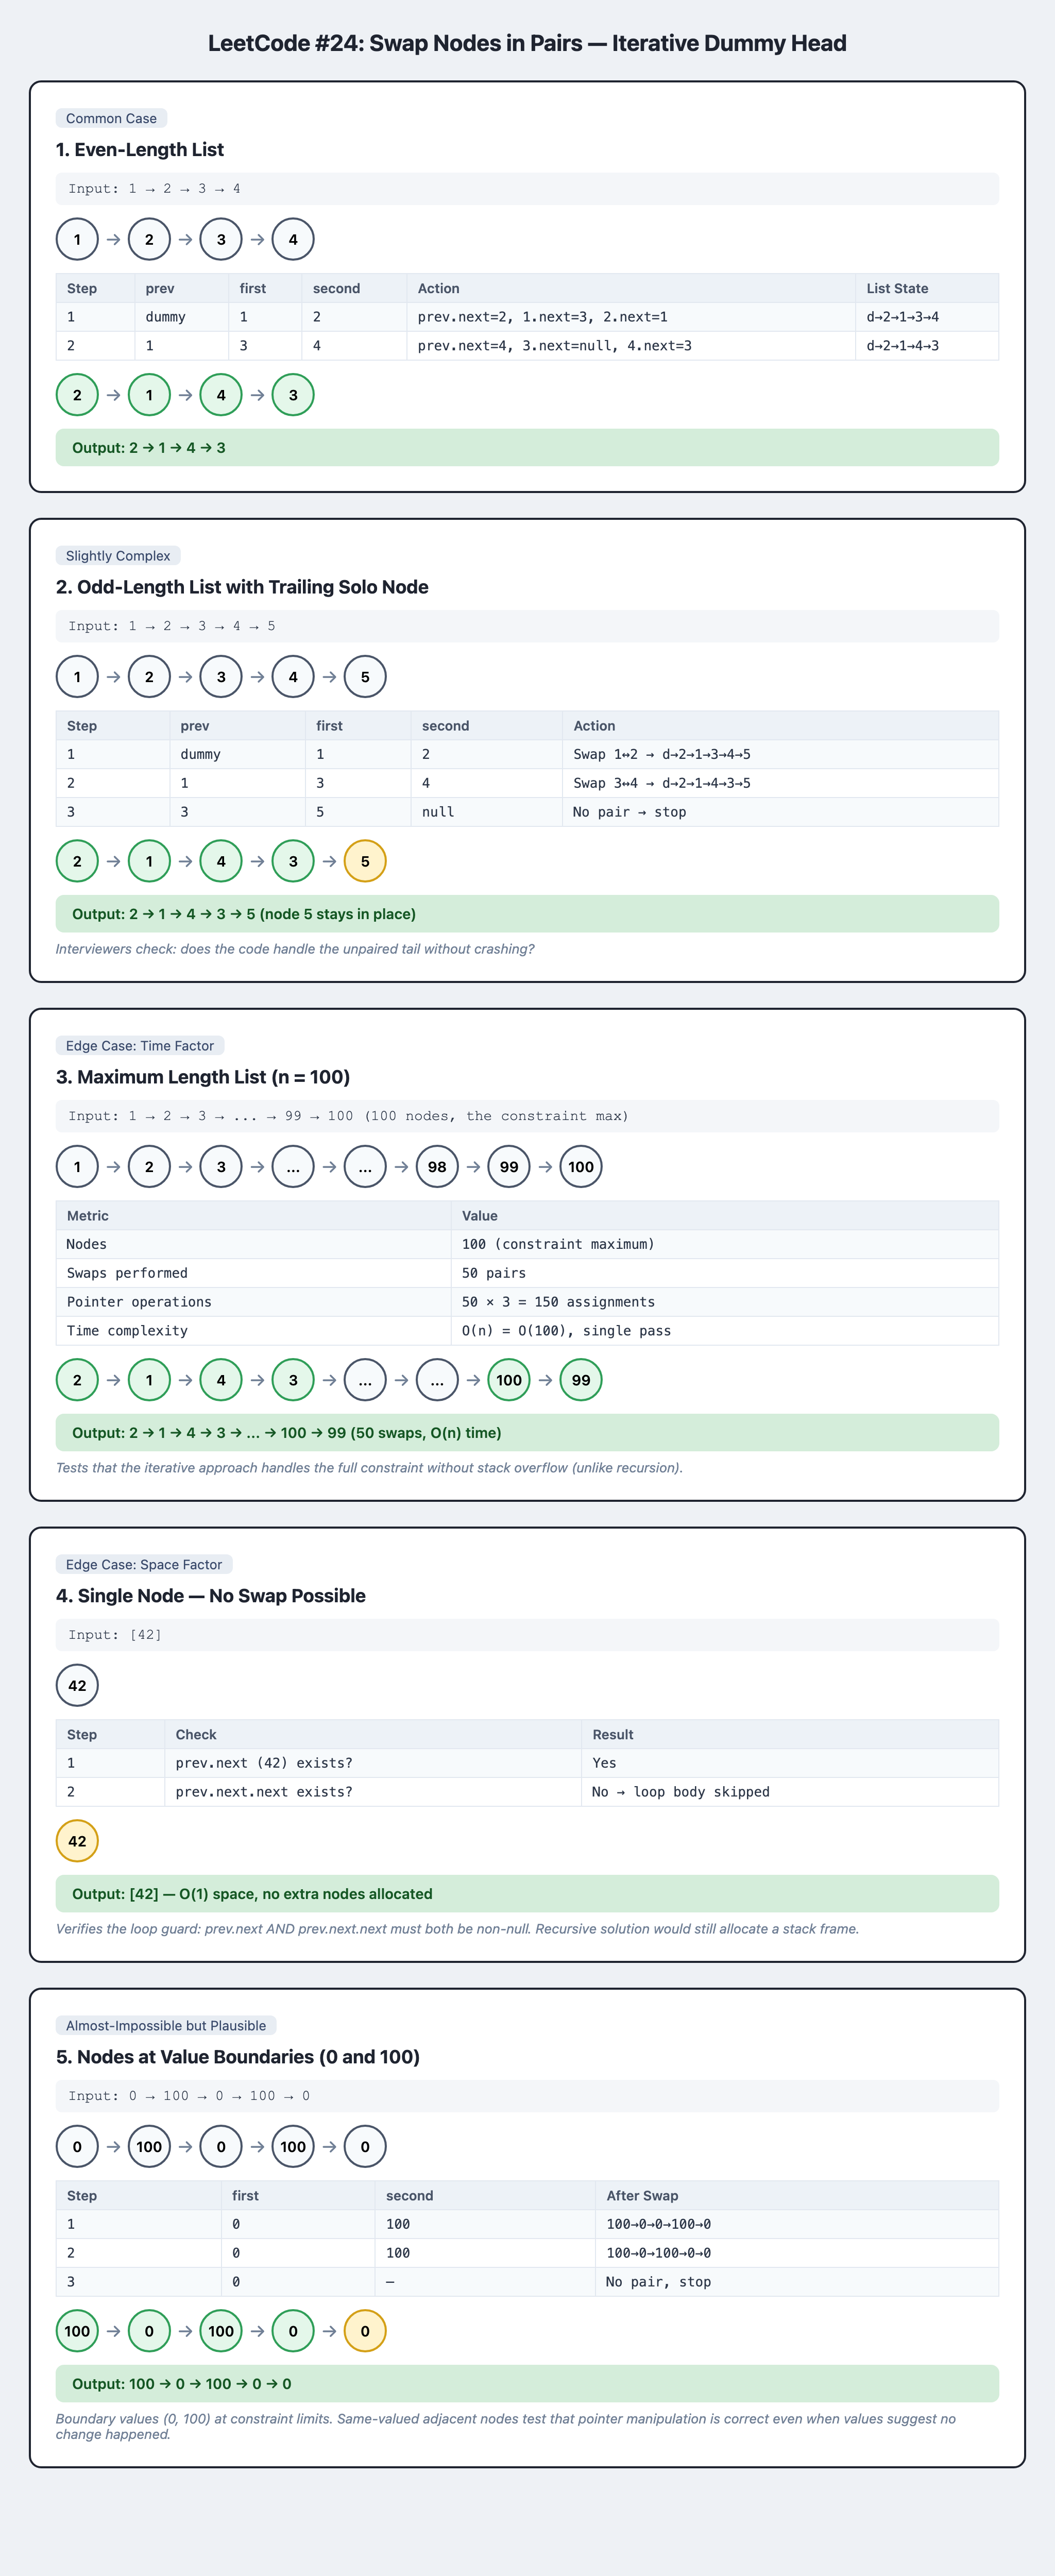